In [11]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binom, poisson, expon, norm, uniform, weibull_min, mode

___

## Задание 1: Визуальный анализ распределений случайных величин
### Постройте гистограмы для следующих распределений:
1. Равномерное с параметрами (0, 1)
2. Нормальное распределение с параметрами mu=0, sigma=1
3. Распределение Вейбулла с x = 10, c = 7 (взять функцию weibull_min из scipy.stats)

___

In [12]:
#одна фигура с подграфиками
import matplotlib.pyplot as plt

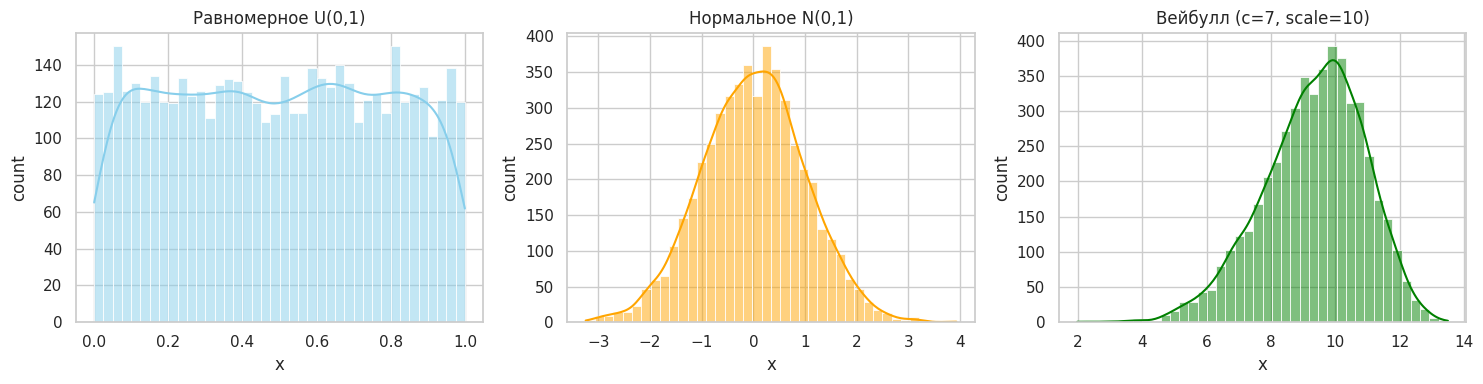

In [13]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data_uniform = uniform.rvs(loc=0, scale=1, size=5000, random_state=42)
sns.histplot(data_uniform, bins=40, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("Равномерное U(0,1)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("count")

data_norm = norm.rvs(loc=0, scale=1, size=5000, random_state=42)
sns.histplot(data_norm, bins=40, kde=True, color="orange", ax=axes[1])
axes[1].set_title("Нормальное N(0,1)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("count")

data_weibull = weibull_min.rvs(c=7, scale=10, size=5000, random_state=42)
sns.histplot(data_weibull, bins=40, kde=True, color="green", ax=axes[2])
axes[2].set_title("Вейбулл (c=7, scale=10)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()

## Задание 2: Свойства нормального распределения
### Случайная величина имеет нормальное распределение с параметрами mu = 10, sigma = 2.
1. Дайте текстовый ответ, что такое "Правило трёх сигм"?
2. Рассчитайте вероятность того, что случайная величина примет значение больше 16. (Поможет метод cdf)
3. Какому значению случайной величины соответствует 5-й персентиль функции распределения? (Поможет метод ppf)
4. Рассчитайте точную оценку вероятности того, что случайная величина из нормального распределения с такими параметрами не отклонится от математического ожидания больше чем на 2 сигмы. А на 1 сигму?

___

### 1. Правило трёх сигм

Если случайная величина имеет нормальное распределение $N(\mu, \sigma^2)$, то:

- около **68%** данных лежат в пределах $[\mu - \sigma;\, \mu + \sigma]$

- около **95%** данных лежат в пределах $[\mu - 2\sigma;\, \mu + 2\sigma]$

- около **99.7%** данных лежат в пределах $[\mu - 3\sigma;\, \mu + 3\sigma]$


In [14]:
#Пункт 2
mu, sigma = 10, 2

# вероятность P(X > 16) = 1 - P(X <= 16) = 1 - CDF(16)
p = 1 - norm.cdf(16, loc=mu, scale=sigma)
print("P(X > 16) = ", p)

P(X > 16) =  0.0013498980316301035


Ответ - примерно 0.135%

In [15]:
#Пункт 3
mu, sigma = 10, 2

# 5-й персентиль
x_5 = norm.ppf(0.05, loc=mu, scale=sigma)
print("5-й перcентиль =", x_5)

5-й перcентиль = 6.710292746097054


Ответ - примерно 6.71

In [16]:
#Пункт 4

#вероятность попадания в ±2σ: P = CDF(𝜇+2*σ) - CDF(𝜇-2*σ)
mu, sigma = 10, 2
p_2sigma = norm.cdf(mu + 2*sigma, loc=mu, scale=sigma) - norm.cdf(mu - 2*sigma, loc=mu, scale=sigma)

#вероятность попадания в ±1σ: P = CDF(𝜇+σ) - CDF(𝜇-σ)
p_1sigma = norm.cdf(mu + sigma, loc=mu, scale=sigma) - norm.cdf(mu - sigma, loc=mu, scale=sigma)

print("P(|X-μ| ≤ 2σ) =", p_2sigma)
print("P(|X-μ| ≤ 1σ) =", p_1sigma)

P(|X-μ| ≤ 2σ) = 0.9544997361036416
P(|X-μ| ≤ 1σ) = 0.6826894921370859


Получили результаты, полностью соответствующие правилу трёх сигм.

## Задание 3: Зависимые случайные величины
### Что такое зависимые случайные величины, дайте развёрнутый текстовый ответ?

Пусть имеется случайная величина ${X}$ из равномерного распределения с параметрами (0, 1). Вторая случайная величина, ${Y}$, получена путём возведения первой в квадрат и прибавления единицы. Будут ли эти случайные величины зависимы? С помощью какой статистики можно оценить "меру зависимости" двух этих случайных величин?

Рассмотрим случайную величину ${X + Y}$. Напишите формулы, по которым считаются математическое ожидание и дисперсия для суммы зависимых случаных величин. Рассчитайте математическое ожидание и диспресию случайной величины ${X + Y}$, сгенерировав распределения ${X}$ и ${Y}$. Достаточно будет 1000 наблюдений.

___

1.

Дискретный случай. Случайные величины $X$ и $Y$ независимы, если для всех $(x,y)$
$$
\mathbb{P}(X=x,\,Y=y)=\mathbb{P}(X=x)\,\mathbb{P}(Y=y).
$$
Если равенство нарушается при некоторых значениях x и y, величины зависимы.

Непрерывный случай. Если существует совместная плотность $f_{X,Y}$, то $X$ и $Y$ независимы, если для всех $(x,y)$
$$
f_{X,Y}(x,y)=f_X(x)\,f_Y(y),
$$
где $f_X, f_Y$ — так называемые маргинальные плотности. Иначе — зависимы.

Исходя из этих определений вводятся понятия попарной независимости случайных величин и независимости в совокупности(когда случайных величин больше, чем две).

2.

Если бы $X$ и $Y$ были независимыми, совместное распределение имело бы ненулевую плотность на всём прямоугольнике $(0,1)\times(1,2)$ в силу факторизации на две маргинальные плотности:
$$
f_X(x) =
\begin{cases}
1, & 0 < x < 1, \\[6pt]
0, & \text{иначе}.
\end{cases}
$$
а
$$
f_Y(y) =
\begin{cases}
\dfrac{1}{2\sqrt{y-1}}, & 1 < y < 2, \\[6pt]
0, & \text{иначе}.
\end{cases}
$$

То есть произведение $f_X(x)$ на $f_Y(y)$ не равно $0$ в прямоугольнике $(0,1)\times(1,2)$
А совместная плотность сосредоточена лишь на кривой $y = x^2 + 1$, то есть на других парах $(x,y)$ внутри прямоугольника $(0,1)\times(1,2)$ совместная плотность равна $0$ — противоречие определению независимости случайных величин(то есть внутри прямоугольника должно быть выполнено свойство $
f_{X,Y}(x,y)=f_X(x)\,f_Y(y)
$). Следовательно, $X$ и $Y$ зависимы статистически(из условия функционально уж тем более).

С помощью корреляции Пирсона можно оценить меру зависимости(линейной) двух этих случайных величин:





### Формула
$$
\rho(X,Y) = \frac{\operatorname{Cov}(X,Y)}{\sqrt{\operatorname{Var}(X)} \cdot \sqrt{\operatorname{Var}(Y)}}.
$$

---

### Расчёты

- По определениям и свойствам мат ожидания и дисперсии(подробно некоторые действия описаны в пункте 3):
$$
\mathbb{E}[X] = \tfrac{1}{2},
\quad \operatorname{Var}(X) = \tfrac{1}{12}.
$$
$$
\mathbb{E}[Y] = \tfrac{4}{3},
\quad \operatorname{Var}(Y) = \tfrac{4}{45}.
$$

- Ковариация(cм. пункт 3):
$$
\operatorname{Cov}(X,Y) = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y].
$$

$$
\mathbb{E}[XY] = \mathbb{E}[X(X^2+1)] = \mathbb{E}[X^3] + \mathbb{E}[X]
= \tfrac{1}{4} + \tfrac{1}{2} = \tfrac{3}{4}.
$$

$$
\mathbb{E}[X]\mathbb{E}[Y] = \tfrac{1}{2} \cdot \tfrac{4}{3} = \tfrac{2}{3}.
$$

$$
\operatorname{Cov}(X,Y) = \tfrac{3}{4} - \tfrac{2}{3} = \tfrac{1}{12}.
$$

---

### Подставляем
$$
\rho = \frac{\tfrac{1}{12}}{\sqrt{\tfrac{1}{12}} \cdot \sqrt{\tfrac{4}{45}}} \rho(X,Y) \approx 0.968.
$$

Значение близко к 1 говорит о сильной положительной связи: при росте X значение Y тоже растёт, но оно не равно 1, то есть зависимость не строго линейная.


3.

### Линейность математического ожидания
$$
\mathbb{E}[X+Y] = \mathbb{E}[X] + \mathbb{E}[Y].
$$

Вывод: через разложение ряда(интеграла) суммы в сумму рядов(интегралов) для дискретных(непрерывных) случайных величин.

### Дисперсия суммы через матожидания
$$
\begin{aligned}
\operatorname{Var}(X+Y)
&= \mathbb{E}\!\big[(X+Y)^2\big] - \big(\mathbb{E}[X+Y]\big)^2 \\
&= \mathbb{E}[X^2] + 2\,\mathbb{E}[XY] + \mathbb{E}[Y^2]
   - \left(\mathbb{E}[X] + \mathbb{E}[Y]\right)^2 \\
&= \big(\mathbb{E}[X^2] - (\mathbb{E}[X])^2\big)
 + \big(\mathbb{E}[Y^2] - (\mathbb{E}[Y])^2\big)
 + 2\big(\mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]\big) \\
&= \operatorname{Var}(X) + \operatorname{Var}(Y) + 2\,\operatorname{Cov}(X,Y).
\end{aligned}
$$

### Ковариация
$$
\operatorname{Cov}(X,Y)=\mathbb{E}[XY]-\mathbb{E}[X]\mathbb{E}[Y].
$$

> Если \(X\) и \(Y\) независимы, то
> $$
> \operatorname{Cov}(X,Y) = 0,
> $$
> поэтому
> $$
> \operatorname{Var}(X+Y) = \operatorname{Var}(X) + \operatorname{Var}(Y).
> $$



## Задано
$X \sim U(0,1)$ — равномерная случайная величина.  
$Y = X^2 + 1$.


---

## 1) Математическое ожидание и дисперсия \(X\)



$$
\mathbb{E}[X] = \int_0^1 x\,dx,  
\quad \operatorname{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2,  
\quad \mathbb{E}[X^2] = \int_0^1 x^2\,dx.
$$



$$
\mathbb{E}[X] = \tfrac{1}{2},  
\quad \mathbb{E}[X^2] = \tfrac{1}{3},
$$

$$
\operatorname{Var}(X) = \tfrac{1}{3} - \left(\tfrac{1}{2}\right)^2 = \tfrac{1}{12} \approx 0.0833.
$$

---

## 2) Математическое ожидание и дисперсия \(Y = X^2+1\)

$$
\mathbb{E}[Y] = \mathbb{E}[X^2] + 1 = \tfrac{1}{3} + 1 = \tfrac{4}{3} \approx 1.3333.
$$

$$
\operatorname{Var}(Y) = \mathbb{E}[X^4] - \left(\mathbb{E}[X^2]\right)^2.
$$

$$
\mathbb{E}[X^4] = \tfrac{1}{5},  
\quad \operatorname{Var}(Y) = \tfrac{1}{5} - \left(\tfrac{1}{3}\right)^2 = \tfrac{4}{45} \approx 0.0889.
$$

Проверка:  

$$
\mathbb{E}[Y^2] = \tfrac{28}{15},  
\quad \operatorname{Var}(Y) = \tfrac{28}{15} - \left(\tfrac{4}{3}\right)^2 = \tfrac{4}{45}.
$$

---

## 3) Сумма \(Z = X+Y\): ожидание и дисперсия

$$
\mathbb{E}[Z] = \mathbb{E}[X] + \mathbb{E}[Y] = \tfrac{1}{2} + \tfrac{4}{3} = \tfrac{11}{6} \approx 1.8333.
$$

$$
\operatorname{Var}(X+Y) = \operatorname{Var}(X) + \operatorname{Var}(Y) + 2\,\operatorname{Cov}(X,Y).
$$

$$
\operatorname{Cov}(X,Y) = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y].
$$

$$
\mathbb{E}[XY] = \mathbb{E}[X^3] + \mathbb{E}[X] = \tfrac{1}{4} + \tfrac{1}{2} = \tfrac{3}{4},
$$

$$
\mathbb{E}[X]\mathbb{E}[Y] = \tfrac{1}{2} \cdot \tfrac{4}{3} = \tfrac{2}{3},
$$

$$
\operatorname{Cov}(X,Y) = \tfrac{3}{4} - \tfrac{2}{3} = \tfrac{1}{12}.
$$

Итог:

$$
\operatorname{Var}(X+Y) = \tfrac{1}{12} + \tfrac{4}{45} + 2 \cdot \tfrac{1}{12} = \tfrac{61}{180} \approx 0.3389.
$$

---

## 4) Результаты
$$
\mathbb{E}[X] = \tfrac{1}{2}, \quad \operatorname{Var}(X) = \tfrac{1}{12};
$$

$$
\mathbb{E}[Y] = \tfrac{4}{3}, \quad \operatorname{Var}(Y) = \tfrac{4}{45};
$$

$$
\mathbb{E}[X+Y] = \tfrac{11}{6} \approx 1.8333, \quad \operatorname{Var}(X+Y) = \tfrac{61}{180} \approx 0.33888.
$$


In [17]:
# Фиксируем seed для воспроизводимости
rng = np.random.default_rng(42)

n = 1000

X = rng.uniform(0, 1, size=n)

Y = X**2 + 1

Z = X + Y

E_Z = Z.mean()
#оценка генеральной дисперсии
Var_Z = Z.var(ddof=0)

print("Математическое ожидание E[X+Y] ≈", E_Z)
print("Дисперсия Var[X+Y] ≈", Var_Z)

Математическое ожидание E[X+Y] ≈ 1.8293008331188267
Дисперсия Var[X+Y] ≈ 0.34353473759455877


## Задание 4: Детектор спама

В таблице `spam_classes.csv` представлены результаты классификации 100 писем, полученных от пользователей. В столбце `is_spam` указано, является ли письмо спамом, а в столбце `marked_spam` — результат работы классификатора.

Задача:
1. Оцените с помощью формулы Байеса вероятность того, что письмо, классифицированное как спам, действительно является спамом. Вероятности, необходимые для применения формулы, рассчитайте по данным в DataFrame
2. С помощью DataFrame посчитайте фактическую вероятность того, что письмо, классифицированное как спам, действительно является спамом.


___

In [18]:
df = pd.read_csv('spam_classes.csv')
df.head()

,is_spam,marked_spam
0,True,True
1,False,True
2,False,False
3,False,False
4,True,False


1.

**Формула Байеса**

$$
P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)},
$$

где:

- \(A\): письмо действительно спам (`is_spam = True`);
- \(B\): классификатор отметил как спам (`marked_spam = True`).

Значит:

$$
P(is\_spam = \text{True} \mid marked\_spam = \text{True}) =
\frac{P(marked\_spam = \text{True} \mid is\_spam = \text{True}) \cdot P(is\_spam = \text{True})}
{P(marked\_spam = \text{True})}.
$$

Значит, необходимо вычислить по данным из DataFrame вероятности, фигурирующие в формуле выше.

In [19]:
p_spam = df['is_spam'].mean()
p_marked = df['marked_spam'].mean()
p_marked_given_spam = df[df['is_spam']]['marked_spam'].mean()
p_spam_given_marked = p_marked_given_spam * p_spam / p_marked
print("P(is_spam=True) =", p_spam)
print("P(marked_spam=True | is_spam=True) =", p_marked_given_spam)
print("P(marked_spam=True) =", p_marked)
print("P(is_spam=True | marked_spam=True) =", p_spam_given_marked)

P(is_spam=True) = 0.46
P(marked_spam=True | is_spam=True) = 0.9130434782608695
P(marked_spam=True) = 0.45
P(is_spam=True | marked_spam=True) = 0.9333333333333332


Вероятность того, что письмо, классифицированное как спам, действительно является спамом = 0.9333333333333332

2.

Фактически это просто доля писем, у которых `is_spam = True` среди тех, у кого `marked_spam = True`:

In [20]:
p_empirical = df[df['marked_spam']]['is_spam'].mean()
print("Фактическая вероятность =", p_empirical)

Фактическая вероятность = 0.9333333333333333


Фактическая вероятность = 0.9333333333333333.

Получили одинаковые значения(отличаются только машинной погрешностью) - закономерный результат.

## Задание 5: Расчет вероятностей исходя из разных распределений

Перед вами ниже находится несколько задач на расчет вероятностей. Ваша задача: определить с помощью какого распределения можно решить задачу и вычислить вероятность с помощью функций плотности распределения из `scipy`.

1. Баскетболист совершает 20 штрафных бросков за игру. Вероятность успеха каждого броска составляет 70%. Какова вероятность того, что игрок совершит не менее 15 бросков?
2. Время между прибытиями автобусов составляет в среднем 10 минут. Какова вероятность того, что автобус прибудет в течение 5 минут?
3. Средний рост взрослого человека составляет 170 см, дисперсия составляем - 100 см. Какова вероятность того, что случайно выбранный взрослый человек имеет рост от 160 до 180 см?
4. В большом лесу среднее количество медведей составляет 2 особи на квадратный километр. Какова вероятность встретить 5 и более медведей на квадратном километре?

___

1.

Модель: 20 независимых испытаний «успех/неуспех» с одинаковой вероятностью успеха, значит, используем биномиальное распределение с параметрами n = 20, p = 0.7.

In [21]:
p1 = binom.sf(14, n=20, p=0.7)

Если прибытия автобусов моделировать пуассоновским потоком со стационарной интенсивностью λ, то время между событиями T ~ Exp(λ), где λ - интенсивность(сколько событий в среднем происходит в единицу времени) = 1 / scale, scale - параметр масштаба(среднее время между событиями). По условию scale = 10 минут.

In [22]:
p2 = expon.cdf(5, scale=10)

Рост — множество независимых факторов; по ЦПТ стремится к распределению  $\mathcal{N}(\mu, \sigma^2).$

По условию:
$
\mu = 170, \text{дисперсия} = 100 \;\;\Rightarrow\;\; \sigma = 10.
$

Вероятность того, что рост находится в пределах от 160 до 180:  

$$
P(160 \leq X \leq 180) = F(180) - F(160),
$$

где $F(x)$ — функция распределения нормального закона $\mathcal{N}(\mu=170, \sigma=10)$.

In [23]:
p3 = norm.cdf(180, loc=170, scale=10) - norm.cdf(160, loc=170, scale=10)

Cчитаем редкие независимые события в фиксированной области с постоянной средней плотностью  
$\lambda = 2$ на $км^2$ $\;\;\Rightarrow\;\; N \sim \text{Pois}(\lambda).$

$
P(N \geq 5) = 1 - F(4) = \text{sf}(4).
$

In [24]:
p4 = poisson.sf(4, mu=2)

In [25]:
print(p1, p2, p3, p4)

0.41637082944748116 0.3934693402873666 0.6826894921370859 0.052653017343711125


## Задание 6: Распределения статистик, Метод Монте-Карло
### Выборка случайных величин {${X_i}$} взята из равномерного распределения с параметрами (0, 100).
1. С помощью метода Монте-Карло постройте распределение выборочного среднего для выборки {${X_i}$}.
2. Каким будет распределение выборочного среднего и почему?
3. Постройте распределения для выборочных СКО, медианы и 16-го персентиля.

___

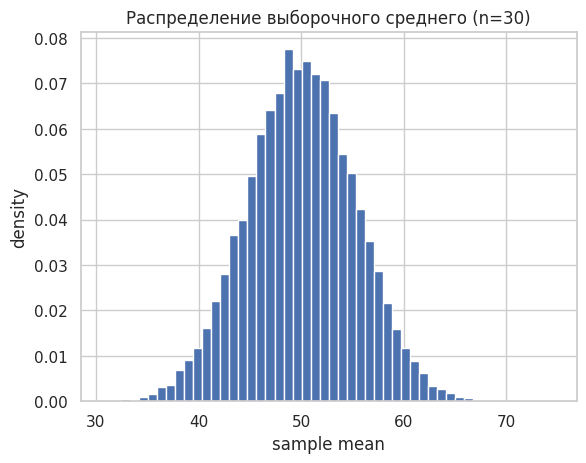

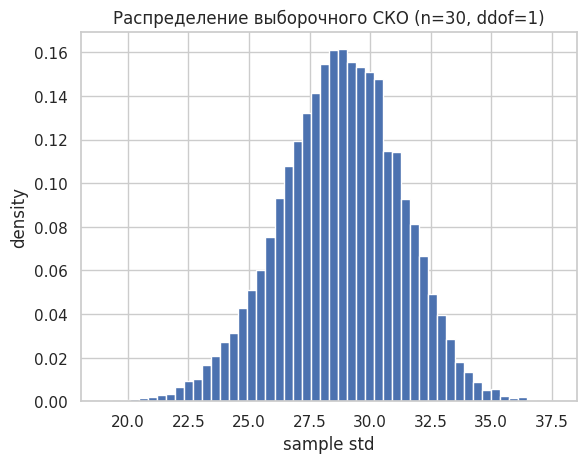

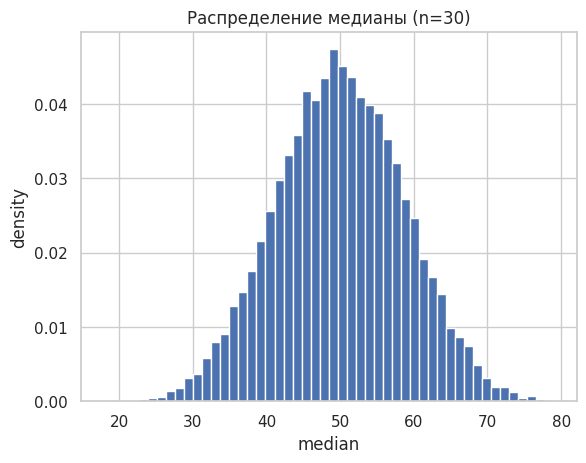

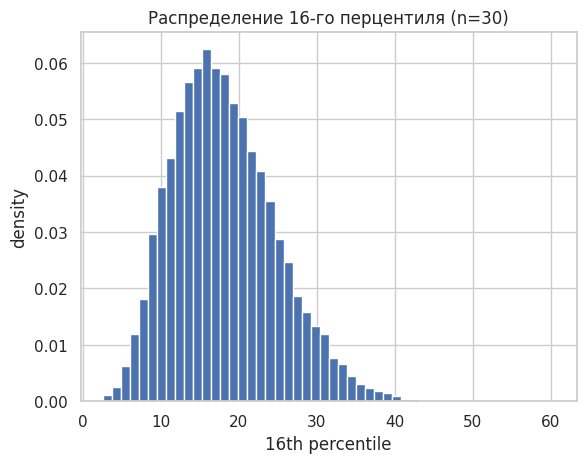

=== Сводка по Монте-Карло ===
Размер выборки n = 30, повторов = 20000
Для X~U(0,100): E[X] = 50.0000, Var[X] = 833.3333

Выборочное среднее:
  эмп. среднее = 50.012108
  эмп. SD(mean) = 5.255023
  теор. E[mean] = 50.000000
  теор. SD(mean) = 5.270463

Выборочное СКО (ddof=1):
  эмп. среднее = 28.765393
  эмп. SD = 2.468245

Медиана:
  эмп. среднее = 50.001859
  эмп. SD = 8.681977

16-й персентиль:
  эмп. среднее = 18.169789
  эмп. SD = 6.641148


In [28]:
rng = np.random.default_rng(0)
a, b = 0.0, 100.0
n = 30
trials = 20000

X = rng.uniform(a, b, size=(trials, n))

sample_means   = X.mean(axis=1)
sample_stds    = X.std(axis=1, ddof=1) #ddof=1 => несмещённая оценка дисперсии(деление на n-1)
sample_medians = np.median(X, axis=1)
sample_p16     = np.percentile(X, 16, axis=1, method='linear')

mu_X = (a + b) / 2
var_X = (b - a)**2 / 12
std_mean_theory = np.sqrt(var_X / n)

plt.figure()
plt.hist(sample_means, bins=50, density=True)
plt.title(f"Распределение выборочного среднего (n={n})")
plt.xlabel("sample mean")
plt.ylabel("density")
plt.show()

plt.figure()
plt.hist(sample_stds, bins=50, density=True)
plt.title(f"Распределение выборочного СКО (n={n}, ddof=1)")
plt.xlabel("sample std")
plt.ylabel("density")
plt.show()

plt.figure()
plt.hist(sample_medians, bins=50, density=True)
plt.title(f"Распределение медианы (n={n})")
plt.xlabel("median")
plt.ylabel("density")
plt.show()

plt.figure()
plt.hist(sample_p16, bins=50, density=True)
plt.title(f"Распределение 16-го перцентиля (n={n})")
plt.xlabel("16th percentile")
plt.ylabel("density")
plt.show()

print("=== Сводка по Монте-Карло ===")
print(f"Размер выборки n = {n}, повторов = {trials}")
print(f"Для X~U(0,100): E[X] = {mu_X:.4f}, Var[X] = {var_X:.4f}")

print("\nВыборочное среднее:")
print(f"  эмп. среднее = {sample_means.mean():.6f}")
print(f"  эмп. SD(mean) = {sample_means.std(ddof=1):.6f}")
print(f"  теор. E[mean] = {mu_X:.6f}")
print(f"  теор. SD(mean) = {std_mean_theory:.6f}")

print("\nВыборочное СКО (ddof=1):")
print(f"  эмп. среднее = {sample_stds.mean():.6f}")
print(f"  эмп. SD = {sample_stds.std(ddof=1):.6f}")

print("\nМедиана:")
print(f"  эмп. среднее = {sample_medians.mean():.6f}")
print(f"  эмп. SD = {sample_medians.std(ddof=1):.6f}")

print("\n16-й персентиль:")
print(f"  эмп. среднее = {sample_p16.mean():.6f}")
print(f"  эмп. SD = {sample_p16.std(ddof=1):.6f}")


Распределение выборочного среднего будет приближаться к нормальному распределению - закономерный результат, вытекающий из ЦПТ. Даже если исходное распределение (у нас равномерное
$U(0,100)$) не нормальное, распределение средних по выборкам будет стремиться к нормальному.